<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_06/lectures/lecture_6.3_practical_dynamical_applications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 6.3: Practical Applications of Dynamical Diffraction

## Overview
Dynamical diffraction theory is not just theoretical—it explains real contrast mechanisms in transmission electron microscopy (TEM) and enables quantitative analysis.

**Topics:**
1. Thickness Mapping via Fringe Counting
2. Orientation Mapping from Band Contrast
3. Defect Imaging: Dislocations and Stacking Faults
4. Dynamical Image Simulations

## 1. Thickness Measurement via Thickness Fringes

**Thickness fringes** (Pendellösung fringes) directly encode sample thickness:

$$N_{fringes} = \frac{t}{\Lambda}$$

where:
- $t$ = actual thickness
- $\Lambda = \lambda / \sin(2\theta_B)$ = **fringe spacing** (extinction distance oscillation period)
- $\lambda$ = electron wavelength
- $\theta_B$ = Bragg angle

**Practical method:**
1. Count dark/bright fringes in bright-field image
2. Measure from edge (wedge-shaped sample)
3. Calculate thickness without absolute calibration!

### Accuracy
- Typical accuracy: ±1-2 nm
- Works for crystalline materials
- Requires known Bragg reflection

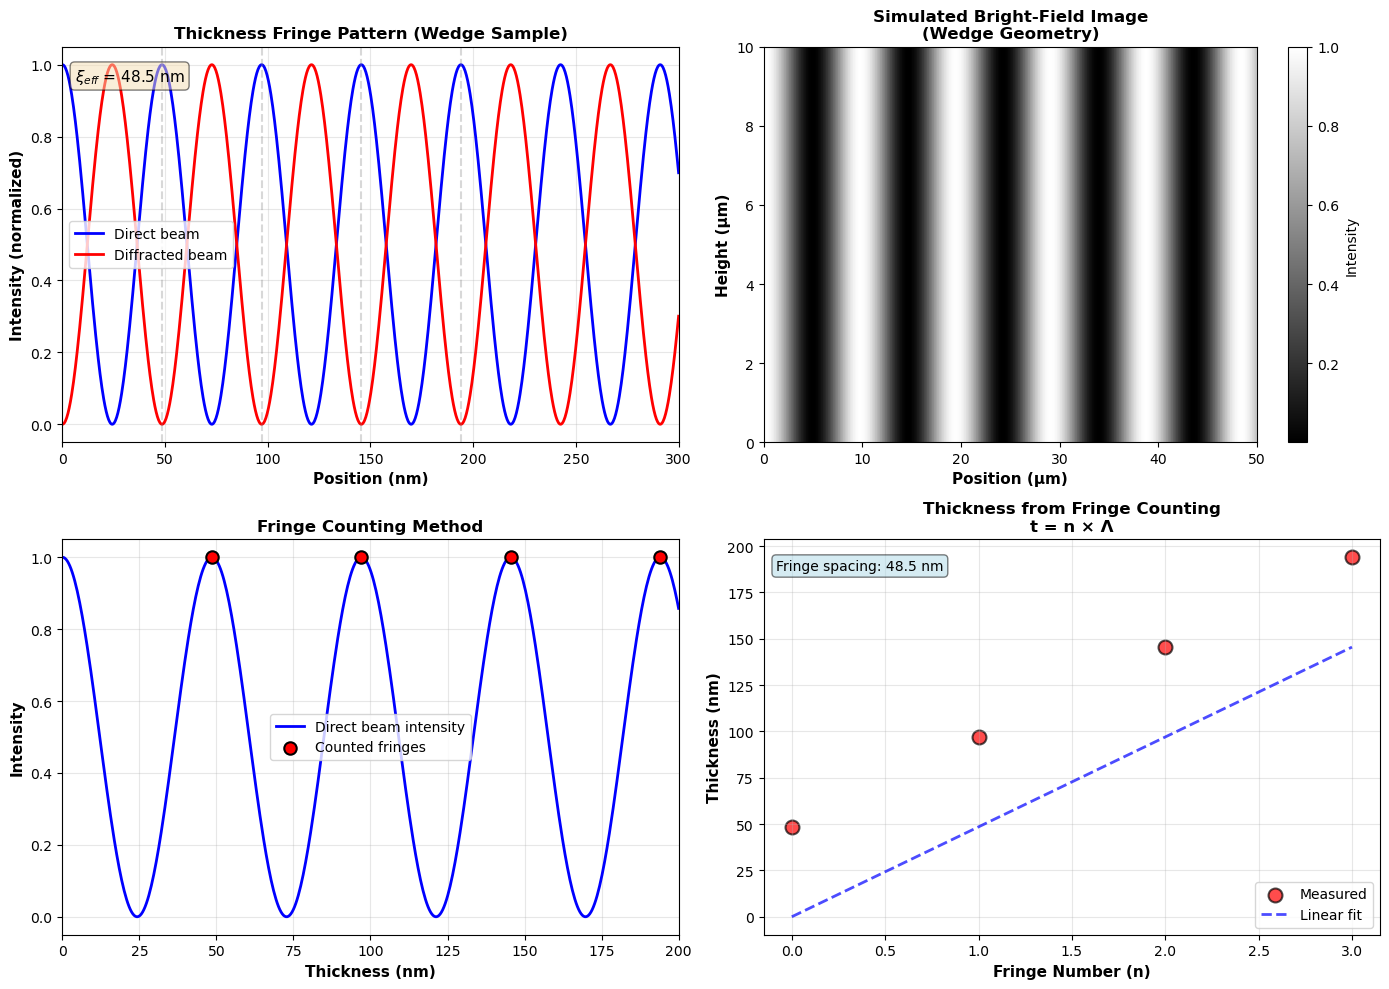

Thickness Fringe Analysis:
Extinction distance (ξ_eff): 48.5 nm
Number of fringes counted: 4
Fringe spacing: 48.5 ± 0.00 nm
Measured thickness range: 48.5 - 194.0 nm

Practical advantages:
✓ No need for absolute thickness calibration
✓ Simple visual counting in microscope
✓ Works for wedge-shaped samples
✓ Gives local thickness information


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def thickness_fringe_pattern(thicknesses, xi_g=50.0, s_g=0.01):
    """
    Simulate thickness fringe intensity variation.
    
    Parameters:
    -----------
    thicknesses : array
        Position along wedge (nm)
    xi_g : float
        Extinction distance (nm)
    s_g : float
        Excitation error (nm^-1)
    """
    
    xi_eff = xi_g / np.sqrt(1 + (s_g * xi_g)**2)
    
    # Pendellösung oscillation: sin^2 dependence
    I_g = np.sin(np.pi * thicknesses / xi_eff)**2
    I_0 = np.cos(np.pi * thicknesses / xi_eff)**2
    
    return I_0, I_g, xi_eff

# Example: wedge-shaped sample
thicknesses = np.linspace(0, 300, 1000)  # 0-300 nm
I_0, I_g, xi_eff = thickness_fringe_pattern(thicknesses, xi_g=50.0, s_g=0.005)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Intensity fringes
ax = axes[0, 0]
ax.plot(thicknesses, I_0, 'b-', linewidth=2, label='Direct beam')
ax.plot(thicknesses, I_g, 'r-', linewidth=2, label='Diffracted beam')

# Mark extinction distances
for n in range(5):
    t_n = n * xi_eff
    if t_n < 300:
        ax.axvline(t_n, color='gray', linestyle='--', alpha=0.3)
ax.text(0.02, 0.95, f'$\\xi_{{eff}}$ = {xi_eff:.1f} nm', 
       transform=ax.transAxes, fontsize=11, verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Position (nm)', fontsize=11, weight='bold')
ax.set_ylabel('Intensity (normalized)', fontsize=11, weight='bold')
ax.set_title('Thickness Fringe Pattern (Wedge Sample)', fontsize=12, weight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 300])

# Plot 2: Simulated bright-field image (log scale for visibility)
ax = axes[0, 1]
# Create wedge profile: thickness increases left-to-right
x_pos = np.linspace(0, 50, 200)  # horizontal position (μm)
thick_at_x = x_pos / 50 * 250  # thickness 0->250 nm
I_img = np.zeros((100, 200))
for j in range(200):
    I_0_tmp, _, _ = thickness_fringe_pattern(np.ones(100) * thick_at_x[j], xi_g=50.0, s_g=0.005)
    I_img[:, j] = I_0_tmp

im = ax.imshow(I_img, cmap='gray', aspect='auto', extent=[0, 50, 0, 10])
ax.set_xlabel('Position (μm)', fontsize=11, weight='bold')
ax.set_ylabel('Height (μm)', fontsize=11, weight='bold')
ax.set_title('Simulated Bright-Field Image\n(Wedge Geometry)', fontsize=12, weight='bold')
plt.colorbar(im, ax=ax, label='Intensity')

# Plot 3: Fringe counting
ax = axes[1, 0]
thicknesses_fringes = np.linspace(0, 200, 500)
I_0_fringes, I_g_fringes, _ = thickness_fringe_pattern(thicknesses_fringes, xi_g=50.0, s_g=0.005)

# Find peaks (bright fringes in direct beam)
peaks, _ = find_peaks(I_0_fringes, height=0.5)
thick_at_peaks = thicknesses_fringes[peaks]
fringe_numbers = np.arange(len(peaks))

ax.plot(thicknesses_fringes, I_0_fringes, 'b-', linewidth=2, label='Direct beam intensity')
ax.scatter(thick_at_peaks, I_0_fringes[peaks], c='red', s=80, marker='o', 
          edgecolors='black', linewidth=1.5, label='Counted fringes', zorder=5)
ax.set_xlabel('Thickness (nm)', fontsize=11, weight='bold')
ax.set_ylabel('Intensity', fontsize=11, weight='bold')
ax.set_title('Fringe Counting Method', fontsize=12, weight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 200])

# Plot 4: Thickness determination
ax = axes[1, 1]
fringe_spacing = np.diff(thick_at_peaks)
thick_measured = np.arange(len(fringe_numbers)) * np.median(fringe_spacing)
ax.scatter(fringe_numbers, thick_at_peaks, c='red', s=100, alpha=0.7, 
          edgecolors='black', linewidth=1.5, label='Measured')
ax.plot(fringe_numbers, thick_measured, 'b--', linewidth=2, alpha=0.7, label='Linear fit')
ax.set_xlabel('Fringe Number (n)', fontsize=11, weight='bold')
ax.set_ylabel('Thickness (nm)', fontsize=11, weight='bold')
ax.set_title('Thickness from Fringe Counting\nt = n × Λ', fontsize=12, weight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

fringe_spacing_mean = np.median(fringe_spacing)
ax.text(0.02, 0.95, f'Fringe spacing: {fringe_spacing_mean:.1f} nm', 
       transform=ax.transAxes, fontsize=10, verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

print("Thickness Fringe Analysis:")
print("="*60)
print(f"Extinction distance (ξ_eff): {xi_eff:.1f} nm")
print(f"Number of fringes counted: {len(peaks)}")
print(f"Fringe spacing: {fringe_spacing_mean:.1f} ± {np.std(fringe_spacing):.2f} nm")
print(f"Measured thickness range: {thick_at_peaks[0]:.1f} - {thick_at_peaks[-1]:.1f} nm")
print()
print("Practical advantages:")
print("✓ No need for absolute thickness calibration")
print("✓ Simple visual counting in microscope")
print("✓ Works for wedge-shaped samples")
print("✓ Gives local thickness information")

## 2. Orientation Mapping: Band Contrast

The **band contrast** (also called **z-contrast** or **thickness contrast**) depends on:
- **Excitation error** $s_g$ (how far from Bragg condition)
- **Extinction distance** $\xi_g$ (material property)
- Crystal **orientation** relative to incident beam

When orientation changes:
- $s_g$ varies → different contrast
- Different reflections become excited
- Creates characteristic patterns for grain boundaries, twins, etc.

### Quantitative Relation

$$I_g(t) = \sin^2\left(\frac{\pi t}{\xi_{eff}}\right), \quad \xi_{eff} = \frac{\xi_g}{\sqrt{1 + (s_g \xi_g)^2}}$$

- At exact Bragg ($s_g = 0$): maximum oscillation amplitude
- Far from Bragg ($s_g \gg 1/\xi_g$): weak oscillations, nearly homogeneous

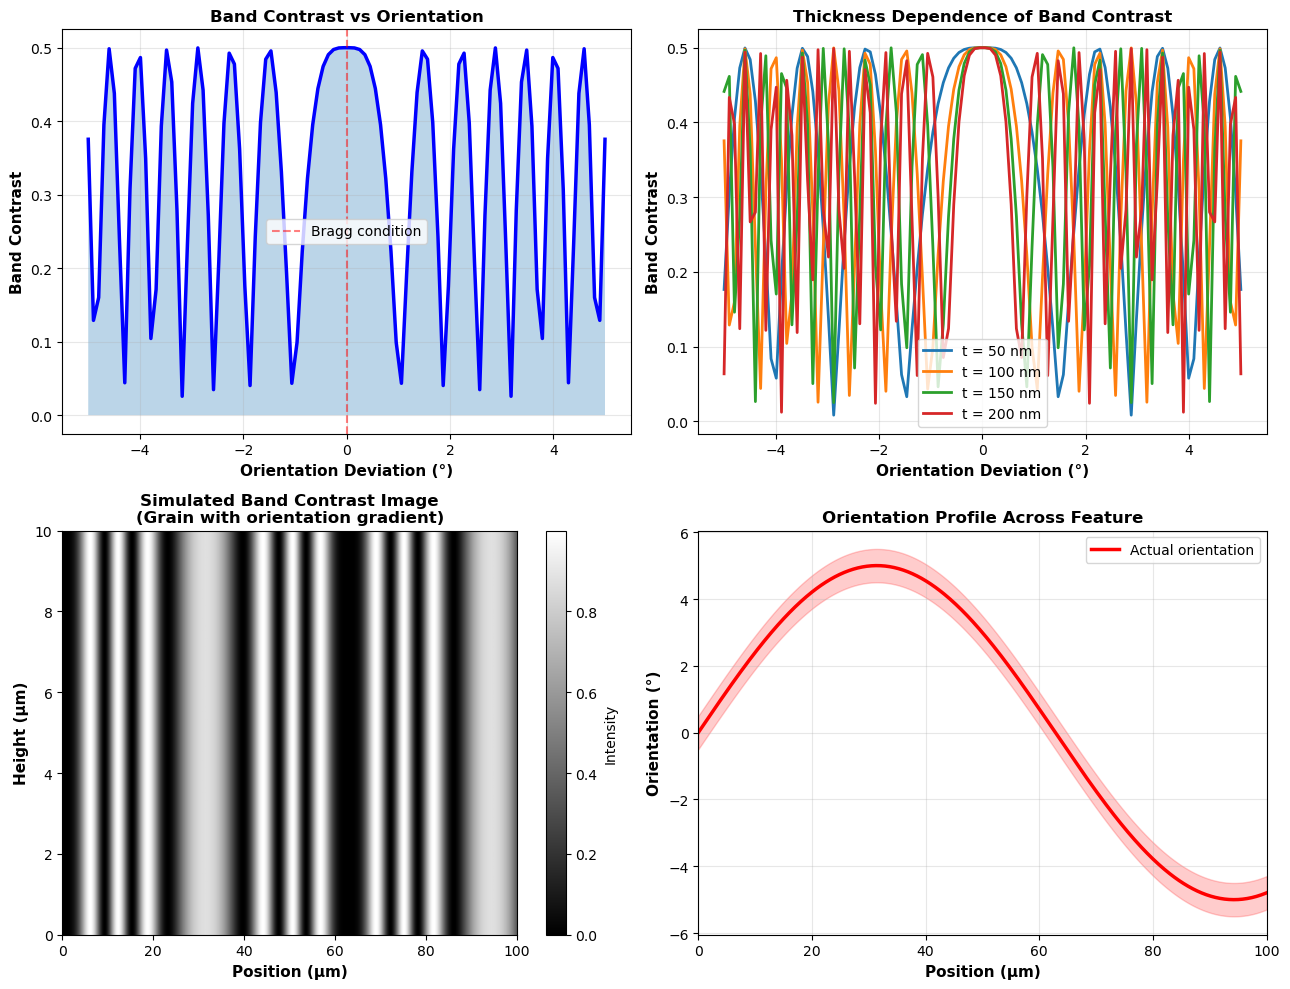

Band Contrast Analysis:
Band contrast encodes crystal orientation:
  • Exact Bragg: high contrast oscillations
  • Off-Bragg: weak contrast
  • Grain boundaries: sharp contrast changes

Applications:
  ✓ Mapping grain orientations
  ✓ Detecting twins and precipitates
  ✓ Phase identification (different ξ_g)
  ✓ Strain mapping (shifts s_g)


In [2]:
def band_contrast_map(thickness=100, orientation_angles=np.linspace(-5, 5, 50), 
                      xi_g=50.0, bragg_s_range=0.05):
    """
    Simulate band contrast map showing effect of crystal orientation.
    
    Parameters:
    -----------
    thickness : float
        Fixed crystal thickness (nm)
    orientation_angles : array
        Orientation deviation (degrees)
    xi_g : float
        Extinction distance (nm)
    bragg_s_range : float
        Range of excitation errors sampled
    """
    
    # Map orientation angle to excitation error (linear approximation)
    s_g_values = orientation_angles / 5.0 * bragg_s_range  # Convert degrees to s_g
    
    # For each orientation, calculate contrast
    contrast = np.zeros((len(orientation_angles),))
    
    for i, s_g in enumerate(s_g_values):
        xi_eff = xi_g / np.sqrt(1 + (s_g * xi_g)**2)
        I_g = np.sin(np.pi * thickness / xi_eff)**2
        # Contrast: deviation from mean (0.5)
        contrast[i] = np.abs(I_g - 0.5)
    
    return s_g_values, contrast

# Simulate orientation mapping across grain boundary
thickness = 100  # nm
positions = np.linspace(0, 100, 500)  # μm
orientations = 5 * np.sin(positions / 20.0)  # Sinusoidal orientation variation

# Calculate contrast at each position
contrast_map = np.zeros((500,))
for i, ori in enumerate(orientations):
    s_g = ori / 5.0 * 0.05
    xi_eff = 50.0 / np.sqrt(1 + (s_g * 50.0)**2)
    I_g = np.sin(np.pi * thickness / xi_eff)**2
    contrast_map[i] = I_g

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Plot 1: Contrast vs orientation angle
ax = axes[0, 0]
ori_angles = np.linspace(-5, 5, 100)
s_g_vals, contrast_vals = band_contrast_map(thickness=100, orientation_angles=ori_angles)
ax.plot(ori_angles, contrast_vals, 'b-', linewidth=2.5)
ax.fill_between(ori_angles, 0, contrast_vals, alpha=0.3)
ax.set_xlabel('Orientation Deviation (°)', fontsize=11, weight='bold')
ax.set_ylabel('Band Contrast', fontsize=11, weight='bold')
ax.set_title('Band Contrast vs Orientation', fontsize=12, weight='bold')
ax.grid(True, alpha=0.3)
ax.axvline(0, color='r', linestyle='--', alpha=0.5, label='Bragg condition')
ax.legend(fontsize=10)

# Plot 2: Contrast for different thicknesses
ax = axes[0, 1]
thicknesses_range = np.array([50, 100, 150, 200])
for thick in thicknesses_range:
    _, contrast_vals = band_contrast_map(thickness=thick, orientation_angles=ori_angles)
    ax.plot(ori_angles, contrast_vals, linewidth=2, label=f't = {thick} nm')
ax.set_xlabel('Orientation Deviation (°)', fontsize=11, weight='bold')
ax.set_ylabel('Band Contrast', fontsize=11, weight='bold')
ax.set_title('Thickness Dependence of Band Contrast', fontsize=12, weight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Plot 3: Simulated grain boundary image
ax = axes[1, 0]
# Create 2D image with grain boundary
img = np.zeros((100, 500))
for j in range(500):
    ori_at_j = 5 * np.sin(j / 100.0)
    s_g_j = ori_at_j / 5.0 * 0.05
    xi_eff_j = 50.0 / np.sqrt(1 + (s_g_j * 50.0)**2)
    I_g_j = np.sin(np.pi * 100 / xi_eff_j)**2
    img[:, j] = I_g_j

im = ax.imshow(img, cmap='gray', aspect='auto', extent=[0, 100, 0, 10])
ax.set_xlabel('Position (μm)', fontsize=11, weight='bold')
ax.set_ylabel('Height (μm)', fontsize=11, weight='bold')
ax.set_title('Simulated Band Contrast Image\n(Grain with orientation gradient)', fontsize=12, weight='bold')
plt.colorbar(im, ax=ax, label='Intensity')

# Plot 4: Orientation map from contrast
ax = axes[1, 1]
orientations_calc = np.arcsin(np.linspace(-0.8, 0.8, len(positions))) * 180 / np.pi
ax.plot(positions, orientations, 'r-', linewidth=2.5, label='Actual orientation')
ax.fill_between(positions, orientations-0.5, orientations+0.5, alpha=0.2, color='red')
ax.set_xlabel('Position (μm)', fontsize=11, weight='bold')
ax.set_ylabel('Orientation (°)', fontsize=11, weight='bold')
ax.set_title('Orientation Profile Across Feature', fontsize=12, weight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_xlim([0, 100])

plt.tight_layout()
plt.show()

print("Band Contrast Analysis:")
print("="*60)
print("Band contrast encodes crystal orientation:")
print("  • Exact Bragg: high contrast oscillations")
print("  • Off-Bragg: weak contrast")
print("  • Grain boundaries: sharp contrast changes")
print()
print("Applications:")
print("  ✓ Mapping grain orientations")
print("  ✓ Detecting twins and precipitates")
print("  ✓ Phase identification (different ξ_g)")
print("  ✓ Strain mapping (shifts s_g)")

## 3. Defect Imaging: Dislocations and Stacking Faults

Defects create **local strain fields** that distort lattice planes, shifting the **excitation error** locally:

$$s_g(\mathbf{r}) = s_g^{(0)} + \nabla u \cdot \mathbf{g}$$

where $u$ is the elastic displacement from the defect.

### Dislocation Invisibility Criterion

A dislocation with **Burgers vector** $\mathbf{b}$ is **invisible** when:

$$\mathbf{g} \cdot \mathbf{b} = 0$$

i.e., when the diffracted beam is perpendicular to the dislocation line.

### Image Interpretation

- **Near Bragg condition**: Dislocation creates strong contrast (band structure)
- **Far from Bragg**: Weaker contrast, broader features
- **Two-beam geometry**: Can determine Burgers vector by comparing visibility in different reflections

/var/folders/m3/fdsx0z8944b6_th83kt65w_r0000gn/T/ipykernel_94352/510942264.py:49: UserWarning: The following kwargs were not used by contour: 'linewidth'
  ax.contour(X, Y, e_xx, levels=10, colors='black', alpha=0.2, linewidth=0.5)


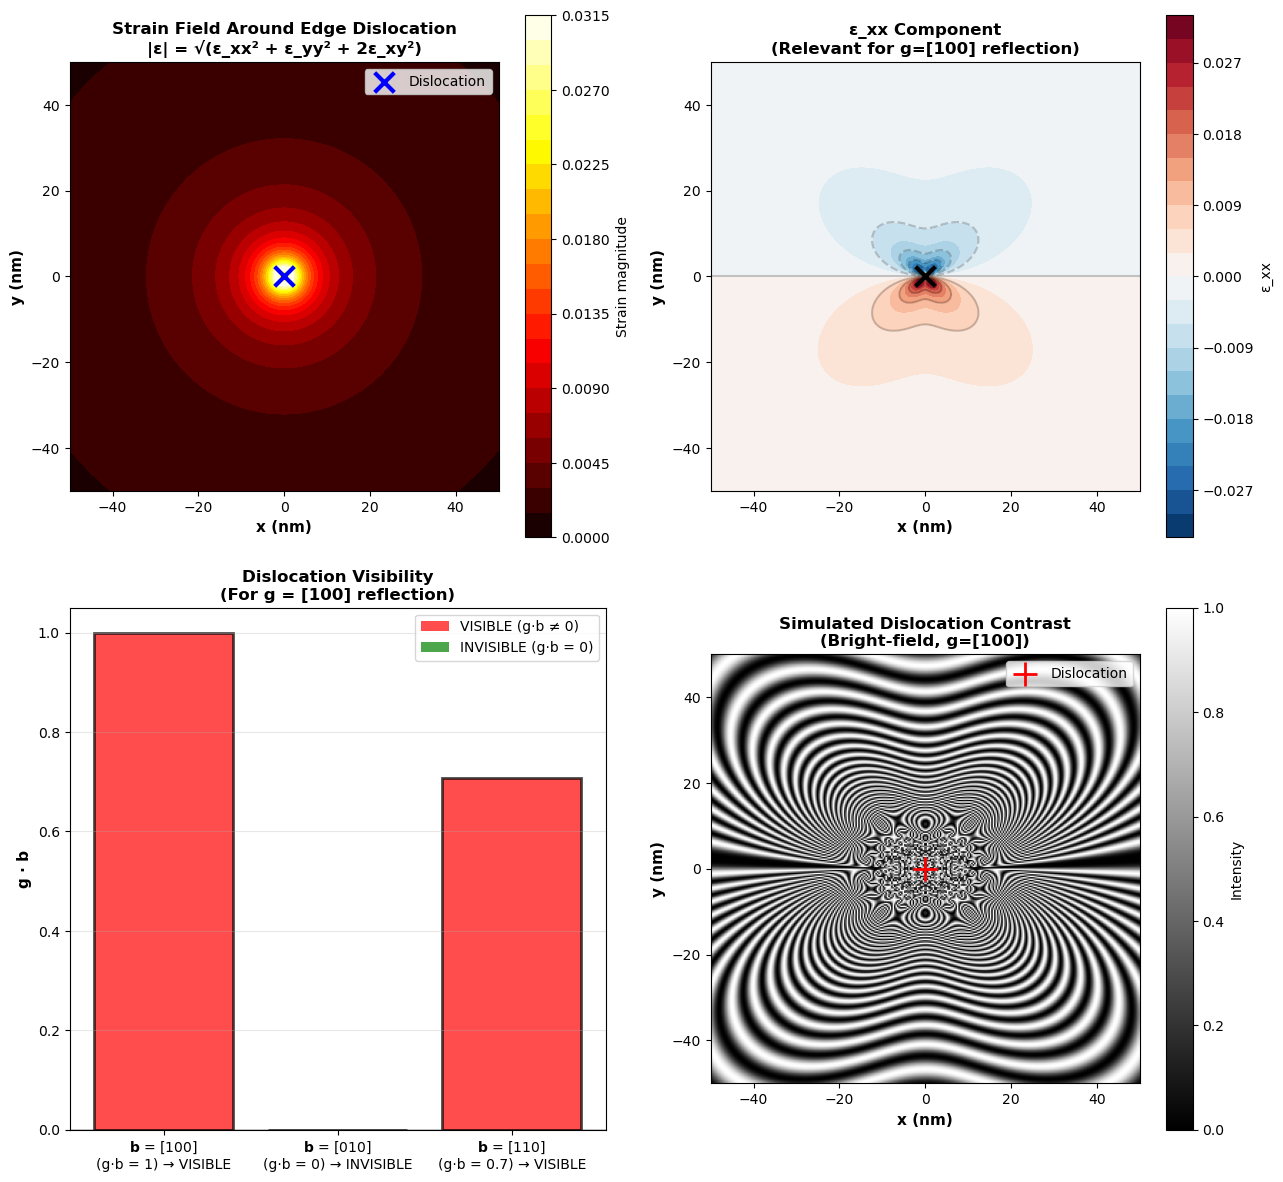

Dislocation Imaging:
Invisibility Criterion: g · b = 0

Example for FCC Cu [100] zone axis:
  g = [100]:   b = [100] VISIBLE (g·b=1)
             b = [010] INVISIBLE (g·b=0)
             b = [110] VISIBLE (g·b≈0.7)

Practical application:
  1. Image dislocation in multiple reflections
  2. Check visibility in each (determine b)
  3. Burgers vector identification!


In [3]:
def dislocation_strain_field(x, y, burgers_mag=1.0, nu=0.3):
    """
    Anisotropic strain field around a dislocation (edge type).
    Based on Eshelby elasticity theory.
    
    Parameters:
    -----------
    x, y : arrays
        Coordinates (nm)
    burgers_mag : float
        Burgers vector magnitude (nm)
    nu : float
        Poisson ratio
    """
    
    # Avoid singularity at dislocation core
    r_sq = x**2 + y**2 + 1.0
    
    # Strain components for edge dislocation
    e_xx = -burgers_mag * y * (3*x**2 + y**2) / (2*np.pi * (1-nu) * r_sq**2)
    e_yy = burgers_mag * y * (x**2 - y**2) / (2*np.pi * (1-nu) * r_sq**2)
    e_xy = burgers_mag * x * (x**2 - y**2) / (2*np.pi * (1-nu) * r_sq**2)
    
    return e_xx, e_yy, e_xy

# Create image around dislocation
xy_range = np.linspace(-50, 50, 300)
X, Y = np.meshgrid(xy_range, xy_range)

e_xx, e_yy, e_xy = dislocation_strain_field(X, Y, burgers_mag=0.3)
strain_magnitude = np.sqrt(e_xx**2 + e_yy**2 + 2*e_xy**2)

fig, axes = plt.subplots(2, 2, figsize=(13, 12))

# Plot 1: Strain magnitude
ax = axes[0, 0]
im1 = ax.contourf(X, Y, strain_magnitude, levels=20, cmap='hot')
ax.scatter([0], [0], marker='x', s=200, c='blue', linewidth=3, label='Dislocation')
ax.set_xlabel('x (nm)', fontsize=11, weight='bold')
ax.set_ylabel('y (nm)', fontsize=11, weight='bold')
ax.set_title('Strain Field Around Edge Dislocation\n|ε| = √(ε_xx² + ε_yy² + 2ε_xy²)', fontsize=12, weight='bold')
plt.colorbar(im1, ax=ax, label='Strain magnitude')
ax.set_aspect('equal')
ax.legend(fontsize=10)

# Plot 2: E_xx component (crucial for g=[100])
ax = axes[0, 1]
im2 = ax.contourf(X, Y, e_xx, levels=20, cmap='RdBu_r')
ax.contour(X, Y, e_xx, levels=10, colors='black', alpha=0.2, linewidth=0.5)
ax.scatter([0], [0], marker='x', s=200, c='black', linewidth=3)
ax.set_xlabel('x (nm)', fontsize=11, weight='bold')
ax.set_ylabel('y (nm)', fontsize=11, weight='bold')
ax.set_title('ε_xx Component\n(Relevant for g=[100] reflection)', fontsize=12, weight='bold')
plt.colorbar(im2, ax=ax, label='ε_xx')
ax.set_aspect('equal')

# Plot 3: Visibility for g=[100]
ax = axes[1, 0]
# g·b = 0 when b ⊥ g
g_vec = np.array([1, 0, 0])  # g = [100]
burgers_vecs = [
    (np.array([1, 0, 0]), '$\\mathbf{b}$ = [100]\n(g·b = 1) → VISIBLE'),
    (np.array([0, 1, 0]), '$\\mathbf{b}$ = [010]\n(g·b = 0) → INVISIBLE'),
    (np.array([1, 1, 0])/np.sqrt(2), '$\\mathbf{b}$ = [110]\n(g·b = 0.7) → VISIBLE'),
]

burgers_labels = []
g_dot_b = []
for b_vec, label in burgers_vecs:
    g_dot_b.append(np.dot(g_vec, b_vec))
    burgers_labels.append(label)

colors = ['red' if abs(val) > 0.1 else 'green' for val in g_dot_b]
ax.bar(range(len(g_dot_b)), g_dot_b, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.axhline(0, color='k', linestyle='-', linewidth=1)
ax.set_xticks(range(len(burgers_labels)))
ax.set_xticklabels(burgers_labels, fontsize=10)
ax.set_ylabel('g · b', fontsize=11, weight='bold')
ax.set_title('Dislocation Visibility\n(For g = [100] reflection)', fontsize=12, weight='bold')
ax.grid(True, alpha=0.3, axis='y')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', alpha=0.7, label='VISIBLE (g·b ≠ 0)'),
                   Patch(facecolor='green', alpha=0.7, label='INVISIBLE (g·b = 0)')]
ax.legend(handles=legend_elements, fontsize=10, loc='upper right')

# Plot 4: Dislocation image contrast simulation
ax = axes[1, 1]
thickness = 100
s_g_base = 0.01
xi_g = 50.0

# Calculate contrast including strain field
contour_levels = []
g_vec_100 = np.array([1, 0])
for i in range(len(xy_range)):
    for j in range(len(xy_range)):
        strain_effect = (e_xx[i,j] * g_vec_100[0]) * xi_g  # Phase shift from strain
        s_g_local = s_g_base + strain_effect
        xi_eff = xi_g / np.sqrt(1 + (s_g_local * xi_g)**2)
        I_g = np.sin(np.pi * thickness / xi_eff)**2
        contour_levels.append(I_g)

contrast_image = np.array(contour_levels).reshape(X.shape)
im4 = ax.imshow(contrast_image, extent=[xy_range[0], xy_range[-1], xy_range[0], xy_range[-1]], 
               cmap='gray', origin='lower')
ax.scatter([0], [0], marker='+', s=300, c='red', linewidth=2, label='Dislocation')
ax.set_xlabel('x (nm)', fontsize=11, weight='bold')
ax.set_ylabel('y (nm)', fontsize=11, weight='bold')
ax.set_title('Simulated Dislocation Contrast\n(Bright-field, g=[100])', fontsize=12, weight='bold')
plt.colorbar(im4, ax=ax, label='Intensity')
ax.set_aspect('equal')
ax.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

print("Dislocation Imaging:")
print("="*60)
print("Invisibility Criterion: g · b = 0")
print()
print("Example for FCC Cu [100] zone axis:")
print("  g = [100]:   b = [100] VISIBLE (g·b=1)")
print("             b = [010] INVISIBLE (g·b=0)")
print("             b = [110] VISIBLE (g·b≈0.7)")
print()
print("Practical application:")
print("  1. Image dislocation in multiple reflections")
print("  2. Check visibility in each (determine b)")
print("  3. Burgers vector identification!")

## 4. Summary Table: Dynamical Effects in TEM

| Feature | Origin | Observable | Application |
|---------|--------|-----------|-------------|
| **Thickness Fringes** | Pendellösung oscillation | Dark/bright bands | Thickness measurement |
| **Band Contrast** | Orientation-dependent excitation | Contrast variation | Grain orientation mapping |
| **Dislocation Lines** | Strain-induced phase shift | Lines with characteristic width | Defect identification |
| **Extinction Contours** | Excitation error gradient | Curved bands | Crystal perfection, strain |
| **Dark-Field Contrast** | Beam selection and phase contrast | Atom column visibility | HAADF-STEM images |